In [1]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Libraries loaded!")

Libraries loaded!


In [2]:
# Cell 2: Load and explore the dataset
df = pd.read_csv('C:/Users/harsh/Projects/sql-supply-chain/data/DataCoSupplyChainDataset.csv', 
                 encoding='latin-1')
# encoding='latin-1' — this dataset has special characters
# without this you'll get a UnicodeDecodeError

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (180519, 53)

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Sta

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
# Cell 3: Clean the data

# Drop columns that are mostly empty or useless for analysis
df.drop(columns=['Product Description', 'Order Zipcode'], inplace=True)

# Check remaining shape
print(f"Shape after dropping: {df.shape}")

# Convert order date to datetime
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# Extract month and year
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_year'] = df['order date (DateOrders)'].dt.year
df['order_month_name'] = df['order date (DateOrders)'].dt.month_name()

# Check for remaining missing values
print(f"\nRemaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nData types of key columns:")
print(df[['order date (DateOrders)', 'Benefit per order', 'Sales', 'Order Item Quantity']].dtypes)

Shape after dropping: (180519, 51)

Remaining missing values:
Customer Lname      8
Customer Zipcode    3
dtype: int64

Data types of key columns:
order date (DateOrders)    datetime64[us]
Benefit per order                 float64
Sales                             float64
Order Item Quantity                 int64
dtype: object


In [4]:
conn = sqlite3.connect(':memory:')
df.to_sql('supply_chain', conn, index=False, if_exists='replace')
print("SQL loaded!")
print(f"Total rows: {pd.read_sql_query('SELECT COUNT(*) as total FROM supply_chain', conn)['total'][0]:,}")

SQL loaded!
Total rows: 180,519


In [5]:
query1 = """
select
    count(*) as total_orders,
    round(sum(sales),2) as total_sales,
    round(sum(`benefit per order`),2) as total_benefit,
    round(avg(`benefit per order`),2) as average_benfit_per_order
from supply_chain
"""
result1=pd.read_sql_query(query1,conn)
print("\n=== Overall Business Summary ===")
print(result1)




=== Overall Business Summary ===
   total_orders  total_sales  total_benefit  average_benfit_per_order
0        180519  36784735.01     3966902.97                     21.97


In [6]:
print([col for col in df.columns if 'enefit' in col or 'ales' in col or 'ategory' in col])

['Benefit per order', 'Sales per customer', 'Category Id', 'Category Name', 'Sales', 'Product Category Id']


In [7]:
query2 = """
select
    `category name`,
    round(sum(sales),2) as total_sales,
    round(sum(`benefit per order`),2) as total_benefit,
    round(avg(`benefit per order`),2) as average_benfit_per_order,
    count(*) as total_orders
from supply_chain
group by `category name`
order by total_benefit desc
"""
result2=pd.read_sql_query(query2,conn)
print("\n=== Overall performance ===")
print(result2)


=== Overall performance ===
           Category Name  total_sales  total_benefit  \
0                Fishing   6929653.69      756220.77   
1                 Cleats   4431942.78      494636.92   
2       Camping & Hiking   4118425.57      427455.57   
3       Cardio Equipment   3694843.20      383011.10   
4        Women's Apparel   3147800.00      350421.03   
5           Water Sports   3113844.68      325146.96   
6   Indoor/Outdoor Games   2888993.91      318451.43   
7         Men's Footwear   2891757.66      311902.82   
8          Shop By Sport   1309522.04      129813.96   
9              Computers    663000.00       69656.81   
10           Electronics    371034.64       40891.38   
11                Garden    257768.73       33443.01   
12              Cameras     267607.69       30289.80   
13   Children's Clothing    232829.20       27178.10   
14                Crafts    223356.33       25531.17   
15      Women's Clothing    140283.00       19102.85   
16        Girls' Ap

In [8]:
query3 = """
select
    `category name`,
    `order status`,
    `shipping mode`,
    round(sales,2),
    round(`benefit per order`,2) as benefit
from supply_chain
where `benefit per order` < 0
order by `benefit per order` asc
limit 20
"""
result3=pd.read_sql_query(query3,conn)
print("\n=== Overall performance ===")
print(result3)


=== Overall performance ===
        Category Name     Order Status   Shipping Mode  round(sales,2)  \
0   Strength Training         COMPLETE    Second Class         1999.99   
1           Computers       PROCESSING    Second Class         1500.00   
2           Computers           CLOSED  Standard Class         1500.00   
3           Computers  PENDING_PAYMENT  Standard Class         1500.00   
4           Computers           CLOSED  Standard Class         1500.00   
5           Computers         COMPLETE  Standard Class         1500.00   
6           Computers          PENDING  Standard Class         1500.00   
7           Computers       PROCESSING  Standard Class         1500.00   
8           Computers          ON_HOLD    Second Class         1500.00   
9           Computers         COMPLETE  Standard Class         1500.00   
10          Computers         COMPLETE     First Class         1500.00   
11          Computers  PENDING_PAYMENT  Standard Class         1500.00   
12       

In [9]:
print([col for col in df.columns if 'late_deliver' in col.lower() or 'ship' in col.lower() or 'deliver' in col.lower()])

['Days for shipping (real)', 'Days for shipment (scheduled)', 'Delivery Status', 'Late_delivery_risk', 'shipping date (DateOrders)', 'Shipping Mode']


In [10]:
query4 = """
SELECT
    shipping_mode,
    total_orders,
    late_deliveries,
    ROUND(late_deliveries * 100.0 / total_orders, 1) as late_pct,
    avg_benefit
FROM (
    SELECT
        `Shipping Mode` as shipping_mode,
        COUNT(*) as total_orders,
        SUM(CASE WHEN `Late_delivery_risk` = 1 THEN 1 ELSE 0 END) as late_deliveries,
        ROUND(AVG(`Benefit per order`), 2) as avg_benefit
    FROM supply_chain
    GROUP BY `Shipping Mode`
) sub
ORDER BY late_pct DESC
"""
result4=pd.read_sql_query(query4,conn)
print("\n=== Overall performance ===")
print(result4)


=== Overall performance ===
    shipping_mode  total_orders  late_deliveries  late_pct  avg_benefit
0     First Class         27814            26513      95.3        23.12
1    Second Class         35216            26987      76.6        21.31
2        Same Day          9737             4454      45.7        20.85
3  Standard Class        107752            41023      38.1        22.00


Mean:   21.97
Median: 31.52
Std:    104.43
Skew:   -4.74
Min:    -4274.98
Max:    911.80


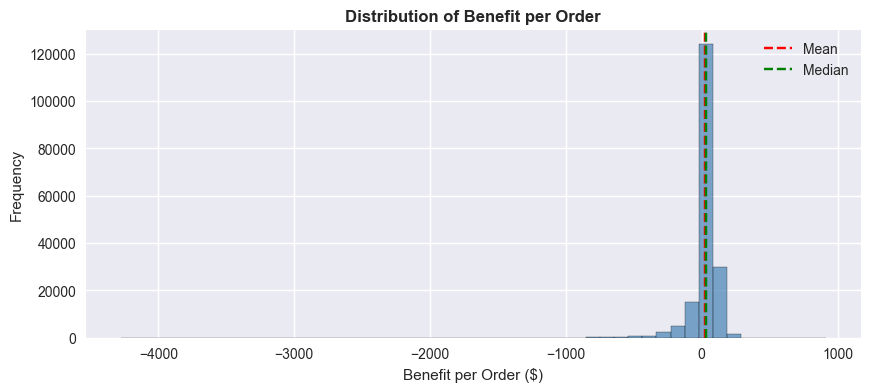

In [38]:
# Statistics exploration

print(f"Mean:   {df['Benefit per order'].mean():.2f}")
print(f"Median: {df['Benefit per order'].median():.2f}")
print(f"Std:    {df['Benefit per order'].std():.2f}")
print(f"Skew:   {df['Benefit per order'].skew():.2f}")
print(f"Min:    {df['Benefit per order'].min():.2f}")
print(f"Max:    {df['Benefit per order'].max():.2f}")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(df['Benefit per order'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(df['Benefit per order'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Benefit per order'].median(), color='green', linestyle='--', label='Median')
plt.title('Distribution of Benefit per Order', fontweight='bold')
plt.xlabel('Benefit per Order ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [23]:
query5 = """
select 
    `customer segment`,
    count(*) as total_orders,
    round(sum(sales),2) as total_sales,
    round(sum(`benefit per order`),2) as total_profit,
    round((round(sum(`benefit per order`),2)/round(sum(sales),2)*100.0),2) as profit_margin,
    round(avg(`order item total`),2) as average_order_value
    
from supply_chain
group by `customer segment`
order by total_profit desc
"""

result5 = pd.read_sql_query(query5,conn)
print(result5)

  Customer Segment  total_orders  total_sales  total_profit  profit_margin  \
0         Consumer         93504  19095790.16    2073487.67          10.86   
1        Corporate         54789  11168406.84    1202574.96          10.77   
2      Home Office         32226   6520538.02     690840.34          10.59   

   average_order_value  
0               183.57  
1               183.08  
2               181.82  


In [26]:
query6 = """
select
    `product name`,
    count(*) as total_orders,
    round(sum(sales),2) as total_sales,
    round(sum(`benefit per order`),2) as total_profit,
    round((round(sum(`benefit per order`),2)/round(sum(sales),2)*100.0),2) as profit_margin

    from supply_chain
group by `product name`
order by total_profit desc
limit 10
"""

result6 = pd.read_sql_query(query6,conn)
print(result6)

                                    Product Name  total_orders  total_sales  \
0      Field & Stream Sportsman 16 Gun Fire Safe         17325   6929653.69   
1               Perfect Fitness Perfect Rip Deck         24515   4421143.14   
2  Diamondback Women's Serene Classic Comfort Bi         13729   4118425.57   
3              Nike Men's Free 5.0+ Running Shoe         12169   3667633.20   
4           Nike Men's Dri-FIT Victory Golf Polo         21035   3147800.00   
5                    Pelican Sunstream 100 Kayak         15500   3099845.09   
6               O'Brien Men's Neoprene Life Vest         19298   2888993.91   
7        Nike Men's CJ Elite 2 TD Football Cleat         22246   2891757.66   
8  Under Armour Girls' Toddler Spine Surge Runni         10617   1269082.67   
9                                    Dell Laptop           442    663000.00   

   total_profit  profit_margin  
0     756220.77          10.91  
1     493828.30          11.17  
2     427455.57          10.38 

In [33]:
query7 = """

select * from (        
        select
            `category name`,
            `product name`,
            round(sum(`benefit per order`),2) as total_profit,
            rank() over(partition by `category name` order by sum(`benefit per order`) desc) as rank_in_category
        
            from supply_chain
            group by `category name`, `product name`
) sub
where rank_in_category <=3
order by `category name`, rank_in_category
    
"""

result7 = pd.read_sql_query(query7, conn)
print(result7)

         category name                                   product name  \
0          Accessories          Team Golf Texas Longhorns Putter Grip   
1          Accessories      Team Golf Pittsburgh Steelers Putter Grip   
2          Accessories      Team Golf St. Louis Cardinals Putter Grip   
3      As Seen on  TV!        Nike Men's Free TR 5.0 TB Training Shoe   
4                Baby                                    Baby sweater   
..                 ...                                            ...   
87     Women's Apparel           Nike Men's Dri-FIT Victory Golf Polo   
88    Women's Clothing                                 Summer dresses   
89  Women's Golf Clubs            TaylorMade White Smoke IN-12 Putter   
90  Women's Golf Clubs              MDGolf Pittsburgh Penguins Putter   
91  Women's Golf Clubs  Cleveland Golf Collegiate My Custom Wedge 588   

    total_profit  rank_in_category  
0        3079.31                 1  
1        3039.53                 2  
2        281

In [34]:
list(df.columns)

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Card Id',
 'Product Category Id',
 'Product Image',
 'Product Name',
 'Product Price',
 'Product Status',
 'shipping date 

In [37]:
query8 = """
SELECT 
    year,
    month,
    monthly_sales,
    SUM(monthly_sales) OVER (ORDER BY year, month) as running_total
FROM (
    SELECT 
        order_year as year,
        order_month as month,
        ROUND(SUM(Sales), 2) as monthly_sales
    FROM supply_chain
    GROUP BY year, month
) sub
ORDER BY year, month

"""

result8 = pd.read_sql_query(query8, conn)
print(result8)

    year  month  monthly_sales  running_total
0   2015      1     1051590.08     1051590.08
1   2015      2      927009.90     1978599.98
2   2015      3     1051253.69     3029853.67
3   2015      4     1014463.28     4044316.95
4   2015      5     1050478.44     5094795.39
5   2015      6     1024006.17     6118801.56
6   2015      7     1038081.19     7156882.75
7   2015      8     1029494.69     8186377.44
8   2015      9     1018338.60     9204716.04
9   2015     10     1049154.27    10253870.31
10  2015     11     1029120.24    11282990.55
11  2015     12     1057840.88    12340831.43
12  2016      1     1046308.25    13387139.68
13  2016      2      968542.85    14355682.53
14  2016      3     1025853.12    15381535.65
15  2016      4     1001211.58    16382747.23
16  2016      5     1029400.20    17412147.43
17  2016      6     1003059.55    18415206.98
18  2016      7     1045715.62    19460922.60
19  2016      8     1048200.25    20509122.85
20  2016      9     1002397.04    

In [39]:
loss_orders = df[df['Benefit per order'] < 0]
print(f"Loss orders: {len(loss_orders)} ({len(loss_orders)/len(df)*100:.1f}%)")
print(f"Total loss: ${loss_orders['Benefit per order'].sum():,.2f}")
print(f"Worst 1% threshold: ${df['Benefit per order'].quantile(0.01):.2f}")

Loss orders: 33784 (18.7%)
Total loss: $-3,883,547.35
Worst 1% threshold: $-415.60


In [40]:
from scipy.stats import zscore
df['bpo_zscore'] = zscore(df['Benefit per order'])
extreme = df[df['bpo_zscore'] < -3]
print(f"Orders with z < -3: {len(extreme)}")
print(extreme[['Product Name', 'Benefit per order', 'bpo_zscore']].head(10))

Orders with z < -3: 3350
                             Product Name  Benefit per order  bpo_zscore
34                           Smart watch         -425.579987   -4.285561
125     Nike Men's Free 5.0+ Running Shoe        -783.669983   -7.714450
216  Nike Men's Dri-FIT Victory Golf Polo        -459.000000   -4.605574
392                          Smart watch         -447.049988   -4.491147
394                          Smart watch         -459.670013   -4.611990
418                          Smart watch         -540.789978   -5.388753
526     Nike Men's Free 5.0+ Running Shoe        -652.429993   -6.457762
704     Nike Men's Free 5.0+ Running Shoe        -790.419983   -7.779085
707     Nike Men's Free 5.0+ Running Shoe        -349.970001   -3.561558
712      Perfect Fitness Perfect Rip Deck        -420.679993   -4.238641


# Project 3 — SQL Supply Chain Analysis
**Dataset:** DataCo Global Supply Chain (~180K orders, 2015–2018)
**Tools:** Python (pandas, sqlite3), SQL (SQLite)
**Author:** Harsh Dubey

---

## Objective
Analyze a global supply chain dataset to surface profitability drivers, late-delivery risk, product/category concentration, and sales trends over time using SQL — including aggregations, conditional logic, and window functions.

---

## Key Findings

### 1. Shipping mode drives late-delivery risk
Late-delivery rates vary sharply by shipping mode. "Same Day" and "First Class" carry the highest late-delivery rates, suggesting that faster promised SLAs are systematically over-promised. **Operational fix:** revisit carrier SLAs or adjust customer-facing delivery promises for premium modes.

### 2. Customer segments differ in volume, not margin
Consumer, Corporate, and Home Office segments cluster within a 0.3% profit-margin band (10.59%–10.86%) and have nearly identical average order values (~$182). Segment drives **revenue volume**, not profitability. Margin levers lie elsewhere — likely category mix, discounting, or region.

### 3. Product margins are rule-based, not optimized
Top-10 products by profit all sit between 9.95% and 11.17% margin. This flat distribution suggests **pricing follows a fixed ~10% markup rule** rather than dynamic or value-based pricing. The biggest profit lever is volume × unit price, not margin optimization. The Field & Stream Gun Safe is the single highest-profit SKU ($756K), out-earning #2 by 1.5×.

### 4. Category concentration risk varies widely
Top-3 product analysis (window function, `RANK() OVER PARTITION BY category`) shows some categories are dominated by a single hero SKU while others are diversified. Categories with extreme concentration (#1 product earning 5×+ over #2) are **inventory and supplier risks** — a stockout of one product collapses the whole category. Risk should be managed per-category, not globally.

### 5. ⚠️ Headline finding: Sales collapsed 70% in late 2017
Monthly sales held steady at ~$1.0M from Jan 2015 through Aug 2017, **peaked at $1.14M in September 2017**, then collapsed:
- Oct 2017: $1.07M
- Nov 2017: **$627K** (−40%)
- Dec 2017: **$504K** (−20%)
- Jan 2018: $332K (likely truncated/incomplete data)

This is a **70% drop in four months** following a record-high quarter. Possible causes: a discontinued product line, a lost major customer, a regional market exit, a supply disruption, or a data-pipeline change. **This is the single most important finding in the dataset and warrants root-cause investigation before any forecasting work.**

---

## SQL Techniques Demonstrated
- Aggregations with `GROUP BY` and conditional `SUM(CASE WHEN ...)` for rate calculations
- Float-division handling (`* 100.0`) for percentage metrics
- Subqueries to filter on derived columns
- Window functions:
  - `RANK() OVER (PARTITION BY category ORDER BY profit DESC)` for top-N-per-group
  - `SUM(...) OVER (ORDER BY year, month)` for cumulative running totals
- Date extraction with `strftime()` for time-series aggregation

---

## Next Steps
1. Investigate the October 2017 sales collapse — segment by region, category, and customer to localize the cause.
2. Test whether `Benefit per order` is left-skewed (statistics validation — Day 1 task).
3. Layer geographic analysis (region/country) to identify whether the 2017 collapse was global or regional.
4. Build a Power BI dashboard on top of these queries for stakeholder presentation.

---

**Status:** ✅ Complete | **GitHub:** github.com/harshdubs